<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




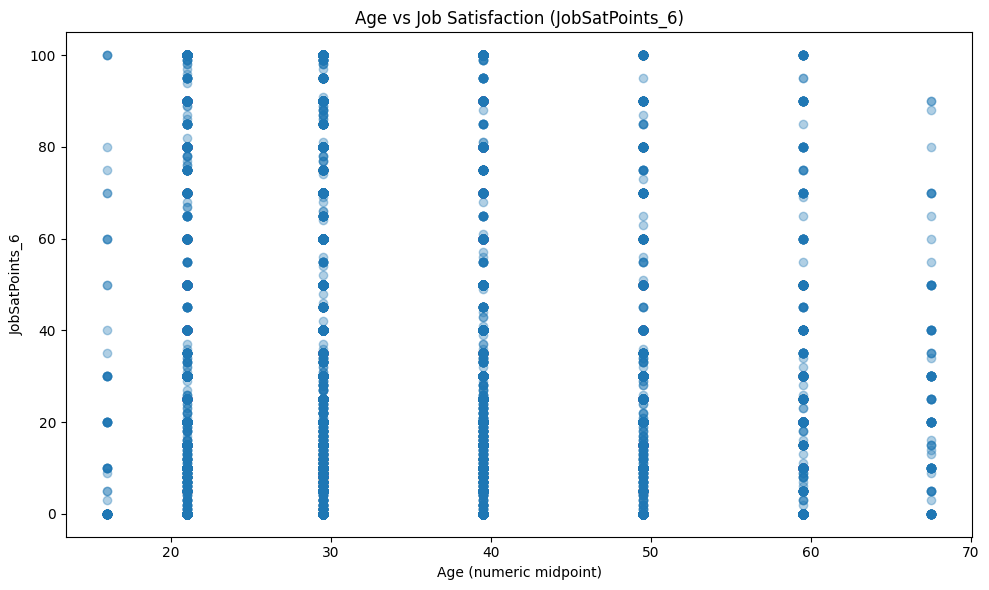

In [3]:
## Write your code here
import numpy as np

def age_to_midpoint(age_str):
    s = str(age_str).strip()
    if s.lower().startswith("under"):
        return 16.0
    if "or older" in s.lower():
        try:
            num = float(s.split()[0])
            return num + 2.5
        except:
            return np.nan
    if "-" in s:
        try:
            left = float(s.split("-")[0])
            right = float(s.split("-")[1].split()[0])
            return (left + right) / 2
        except:
            return np.nan
    try:
        return float(s)
    except:
        return np.nan

df1 = df[["Age", "JobSatPoints_6"]].dropna().copy()
df1["Age_num"] = df1["Age"].apply(age_to_midpoint)
df1["JobSatPoints_6"] = pd.to_numeric(df1["JobSatPoints_6"], errors="coerce")
df1 = df1.dropna(subset=["Age_num", "JobSatPoints_6"])

plt.figure(figsize=(10, 6))
plt.scatter(df1["Age_num"], df1["JobSatPoints_6"], alpha=0.35)
plt.title("Age vs Job Satisfaction (JobSatPoints_6)")
plt.xlabel("Age (numeric midpoint)")
plt.ylabel("JobSatPoints_6")
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


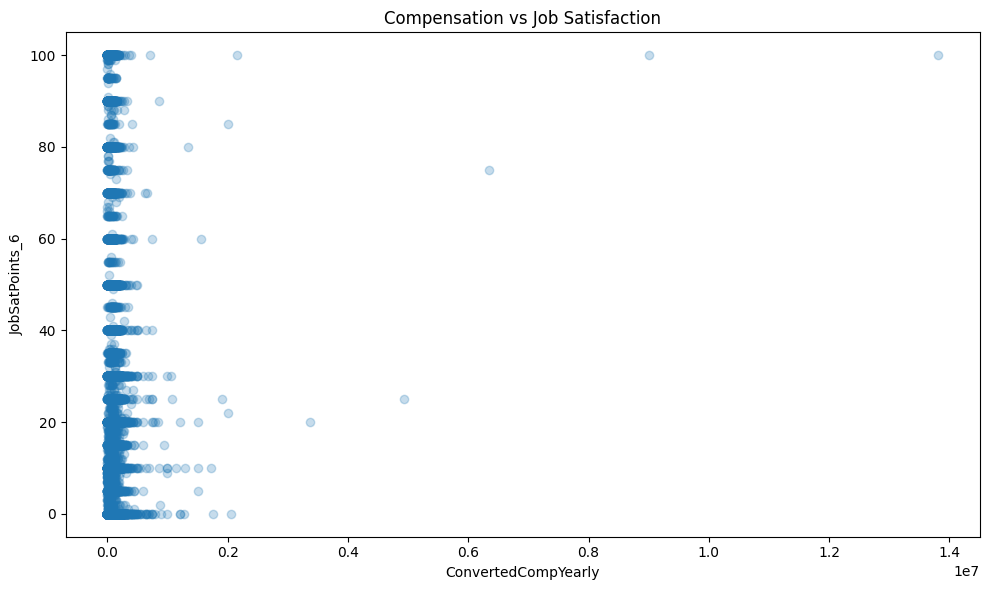

In [4]:
## Write your code here
df2 = df[["ConvertedCompYearly", "JobSatPoints_6"]].dropna().copy()
df2["ConvertedCompYearly"] = pd.to_numeric(df2["ConvertedCompYearly"], errors="coerce")
df2["JobSatPoints_6"] = pd.to_numeric(df2["JobSatPoints_6"], errors="coerce")
df2 = df2.dropna()

# keep positive compensation only
df2 = df2[df2["ConvertedCompYearly"] > 0]

plt.figure(figsize=(10, 6))
plt.scatter(df2["ConvertedCompYearly"], df2["JobSatPoints_6"], alpha=0.25)
plt.title("Compensation vs Job Satisfaction")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("JobSatPoints_6")
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


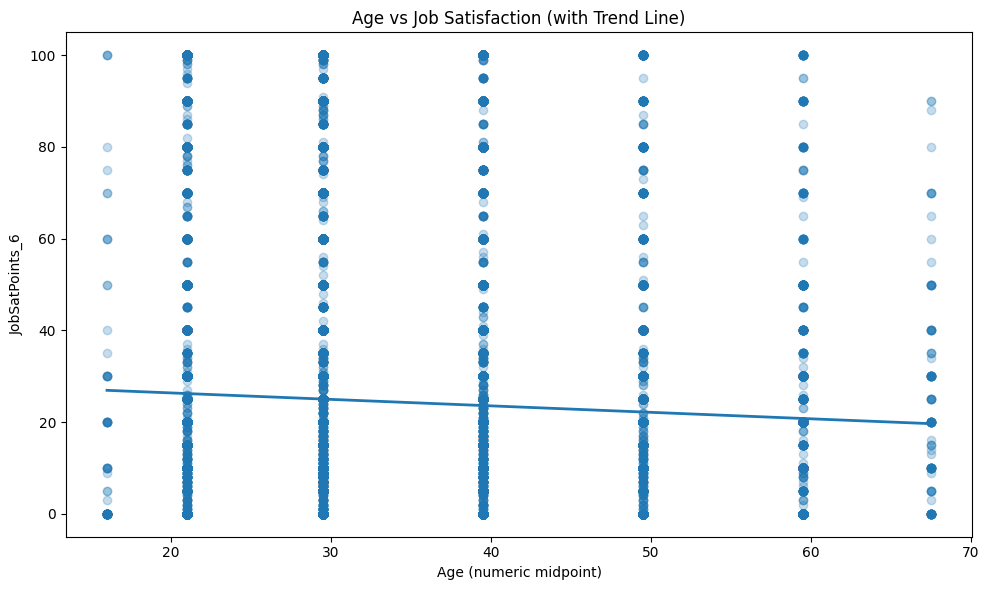

In [5]:
## Write your code here
import numpy as np

df3 = df[["Age", "JobSatPoints_6"]].dropna().copy()
df3["Age_num"] = df3["Age"].apply(age_to_midpoint)
df3["JobSatPoints_6"] = pd.to_numeric(df3["JobSatPoints_6"], errors="coerce")
df3 = df3.dropna(subset=["Age_num", "JobSatPoints_6"])

x = df3["Age_num"].values
y = df3["JobSatPoints_6"].values

# Regression line (degree 1)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_line, y_line, linewidth=2)
plt.title("Age vs Job Satisfaction (with Trend Line)")
plt.xlabel("Age (numeric midpoint)")
plt.ylabel("JobSatPoints_6")
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


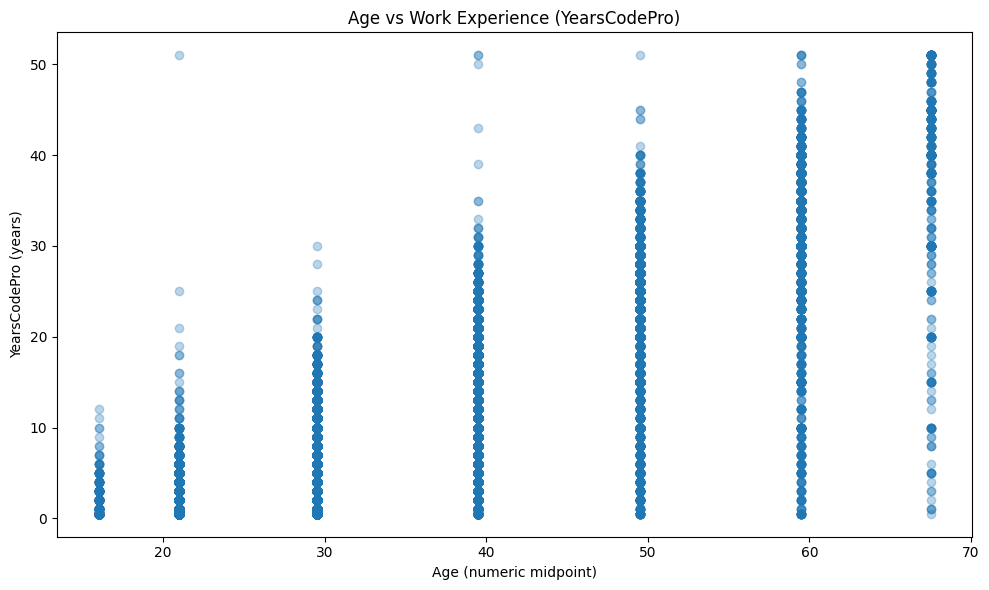

In [6]:
## Write your code here
import numpy as np

df4 = df[["Age", "YearsCodePro"]].dropna().copy()
df4["Age_num"] = df4["Age"].apply(age_to_midpoint)

yc = (
    df4["YearsCodePro"]
    .astype(str)
    .str.strip()
    .replace({"Less than 1 year": "0.5", "More than 50 years": "51"})
)
df4["YearsCodePro_num"] = pd.to_numeric(yc, errors="coerce")

df4 = df4.dropna(subset=["Age_num", "YearsCodePro_num"])

plt.figure(figsize=(10, 6))
plt.scatter(df4["Age_num"], df4["YearsCodePro_num"], alpha=0.3)
plt.title("Age vs Work Experience (YearsCodePro)")
plt.xlabel("Age (numeric midpoint)")
plt.ylabel("YearsCodePro (years)")
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


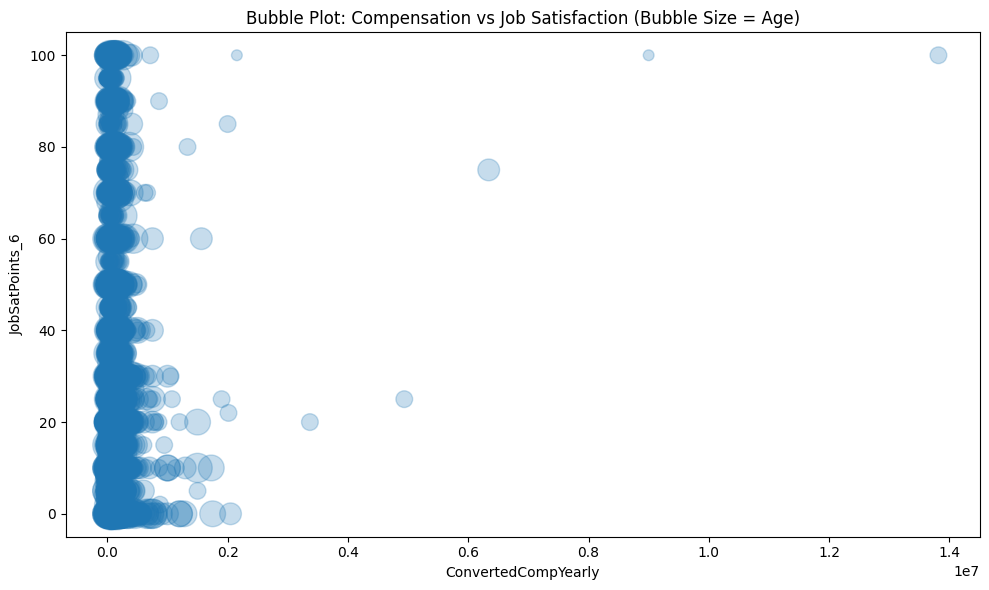

In [7]:
## Write your code here
import numpy as np

df5 = df[["ConvertedCompYearly", "JobSatPoints_6", "Age"]].dropna().copy()
df5["ConvertedCompYearly"] = pd.to_numeric(df5["ConvertedCompYearly"], errors="coerce")
df5["JobSatPoints_6"] = pd.to_numeric(df5["JobSatPoints_6"], errors="coerce")
df5["Age_num"] = df5["Age"].apply(age_to_midpoint)
df5 = df5.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6", "Age_num"])
df5 = df5[df5["ConvertedCompYearly"] > 0]

# bubble sizes (scaled)
sizes = (df5["Age_num"] - df5["Age_num"].min() + 1) * 10

plt.figure(figsize=(10, 6))
plt.scatter(df5["ConvertedCompYearly"], df5["JobSatPoints_6"], s=sizes, alpha=0.25)
plt.title("Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("JobSatPoints_6")
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


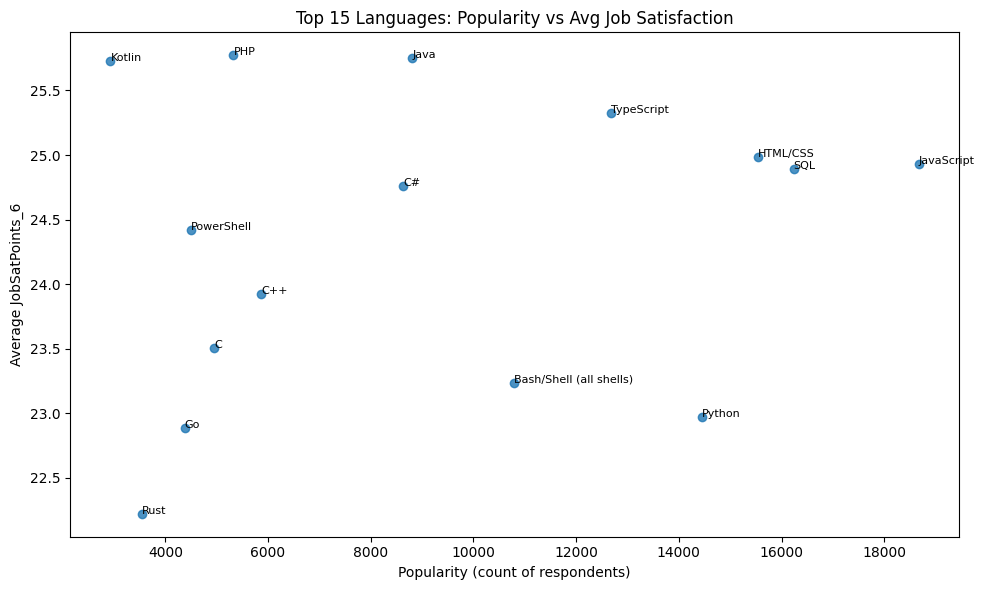

In [8]:
## Write your code here
df6 = df[["LanguageHaveWorkedWith", "JobSatPoints_6"]].dropna().copy()
df6["JobSatPoints_6"] = pd.to_numeric(df6["JobSatPoints_6"], errors="coerce")
df6 = df6.dropna(subset=["JobSatPoints_6"])

lang_exploded = (
    df6.assign(LanguageHaveWorkedWith=df6["LanguageHaveWorkedWith"].astype(str).str.split(";"))
       .explode("LanguageHaveWorkedWith")
)
lang_exploded["LanguageHaveWorkedWith"] = lang_exploded["LanguageHaveWorkedWith"].str.strip()

lang_stats = (
    lang_exploded.groupby("LanguageHaveWorkedWith")
    .agg(
        count=("JobSatPoints_6", "size"),
        avg_satisfaction=("JobSatPoints_6", "mean")
    )
    .sort_values("count", ascending=False)
)

top_lang = lang_stats.head(15).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(top_lang["count"], top_lang["avg_satisfaction"], alpha=0.8)

for _, r in top_lang.iterrows():
    plt.annotate(r["LanguageHaveWorkedWith"], (r["count"], r["avg_satisfaction"]), fontsize=8)

plt.title("Top 15 Languages: Popularity vs Avg Job Satisfaction")
plt.xlabel("Popularity (count of respondents)")
plt.ylabel("Average JobSatPoints_6")
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


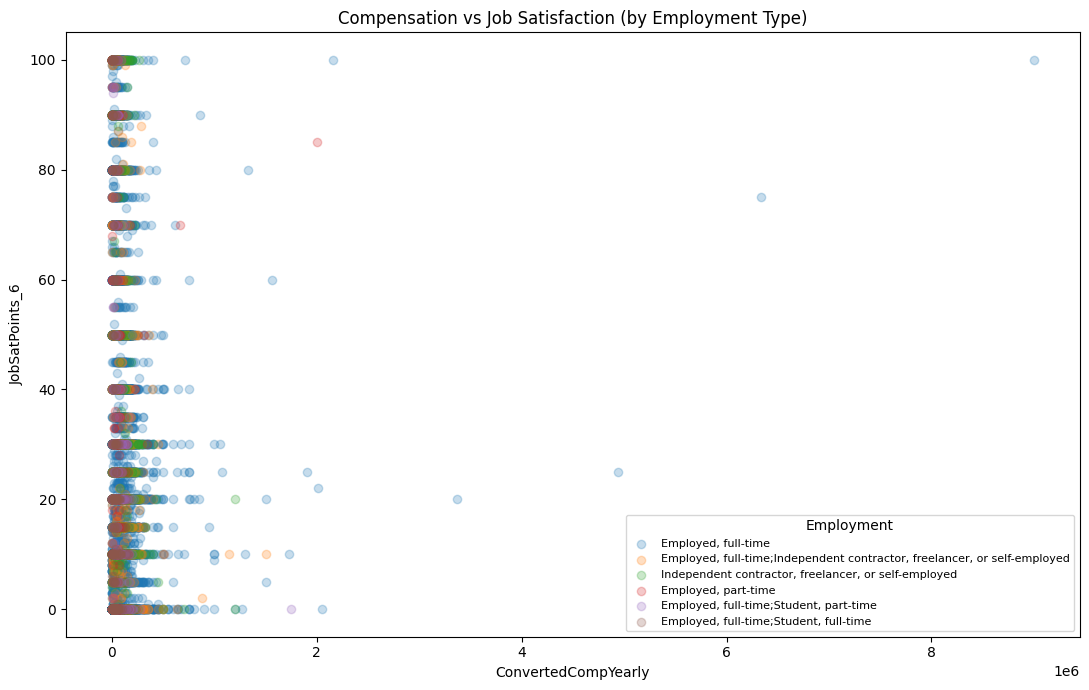

In [9]:
## Write your code here
df7 = df[["ConvertedCompYearly", "JobSatPoints_6", "Employment"]].dropna().copy()
df7["ConvertedCompYearly"] = pd.to_numeric(df7["ConvertedCompYearly"], errors="coerce")
df7["JobSatPoints_6"] = pd.to_numeric(df7["JobSatPoints_6"], errors="coerce")
df7 = df7.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6"])
df7 = df7[df7["ConvertedCompYearly"] > 0]

# keep it readable: top 6 employment types
top_emp = df7["Employment"].value_counts().head(6).index.tolist()
df7 = df7[df7["Employment"].isin(top_emp)]

plt.figure(figsize=(11, 7))
for emp in top_emp:
    sub = df7[df7["Employment"] == emp]
    plt.scatter(sub["ConvertedCompYearly"], sub["JobSatPoints_6"], alpha=0.25, label=emp)

plt.title("Compensation vs Job Satisfaction (by Employment Type)")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("JobSatPoints_6")
plt.legend(title="Employment", fontsize=8)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


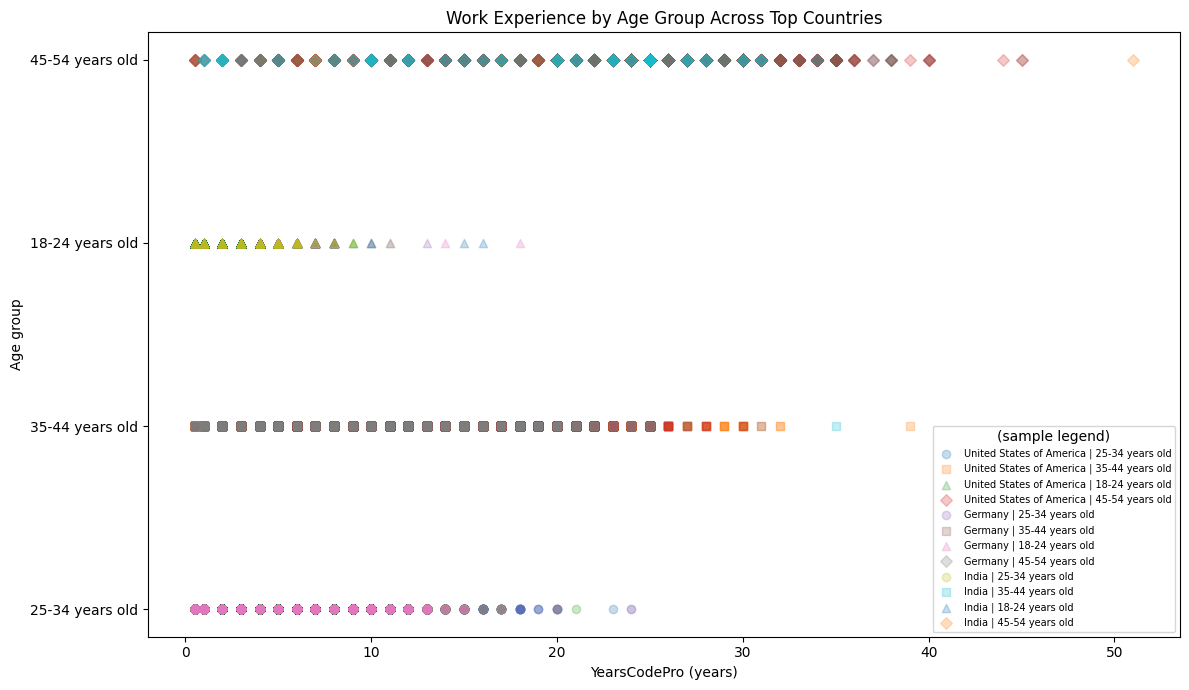

In [10]:
## Write your code here
import numpy as np

df8 = df[["YearsCodePro", "Age", "Country"]].dropna().copy()

yc = (
    df8["YearsCodePro"]
    .astype(str)
    .str.strip()
    .replace({"Less than 1 year": "0.5", "More than 50 years": "51"})
)
df8["YearsCodePro_num"] = pd.to_numeric(yc, errors="coerce")
df8 = df8.dropna(subset=["YearsCodePro_num"])

# Keep age as group label (original category), but limit for readability
top_age_groups = df8["Age"].value_counts().head(4).index.tolist()
df8 = df8[df8["Age"].isin(top_age_groups)]

# Keep top 5 countries
top_countries = df8["Country"].value_counts().head(5).index.tolist()
df8 = df8[df8["Country"].isin(top_countries)]

marker_map = {
    top_age_groups[0]: "o",
    top_age_groups[1]: "s",
    top_age_groups[2]: "^",
    top_age_groups[3]: "D",
}

plt.figure(figsize=(12, 7))
for country in top_countries:
    for age_grp in top_age_groups:
        sub = df8[(df8["Country"] == country) & (df8["Age"] == age_grp)]
        if len(sub) == 0:
            continue
        plt.scatter(
            sub["YearsCodePro_num"],
            [age_grp]*len(sub),   # categorical y-axis
            alpha=0.25,
            marker=marker_map[age_grp],
            label=f"{country} | {age_grp}"
        )

plt.title("Work Experience by Age Group Across Top Countries")
plt.xlabel("YearsCodePro (years)")
plt.ylabel("Age group")
# reduce legend clutter by showing fewer entries:
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:12], labels[:12], fontsize=7, title="(sample legend)", loc="best")
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
